### Libraries and Imports

In [1]:
import sys
sys.path.append("../src")
print(sys.path)

from system import System
from mpcd import streaming, collision, distributeToCells
from observables import system_momentum, system_kinetic

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

['/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python39.zip', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/lib-dynload', '', '/Users/olegoniy/Desktop/MPCD/lib/python3.9/site-packages', '../src']


### System Settings 
#### Solvent

In [2]:
system = System(
    N = 83324, 
    box = [10, 10, 10], 
    a = 1.0, 
    h = 0.1, 
    m = 1.0, 
    kBT = 1.0, 
    alpha_deg=30, 
    seed=1      
    )

### Velocity distribution of solvent particles 
___IMPORTANT!___(I think): Here we observe only 1st component (i.e. x-Direction), not the absolute value of velosities

In [3]:
def velocityDistr(system):

    for i in range(1000):
        streaming(system)
        collision(system)

    vx = system.v[:, 0]

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(vx.min(), vx.max(), 300)

    pdf = (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-x**2 / (2 * sigma**2))
    )

    plt.hist(vx, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()


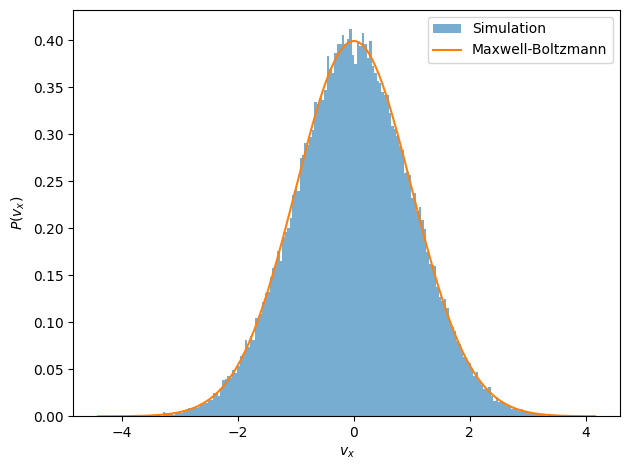

In [4]:
velocityDistr(system)

Here also Gaussian, cause there's no multiplication factor of $v^2$, so probably what was meant in the book

### Velocity Magnitude Distribution

In [5]:
def velocityMagnitudeDistr(system):
    for i in range(1000):
        streaming(system)
        collision(system)

    v_abs = np.sqrt(np.sum(system.v**2, axis=1))

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(v_abs.min(), v_abs.max(), 300)

    pdf = (
        4*np.pi*(1/(2*np.pi*sigma)**(3.0/2))*x**2*np.exp(-x**2/(2*sigma))
    )
    # Since v_abs is a square, the actual values are roots
    plt.hist(v_abs, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()

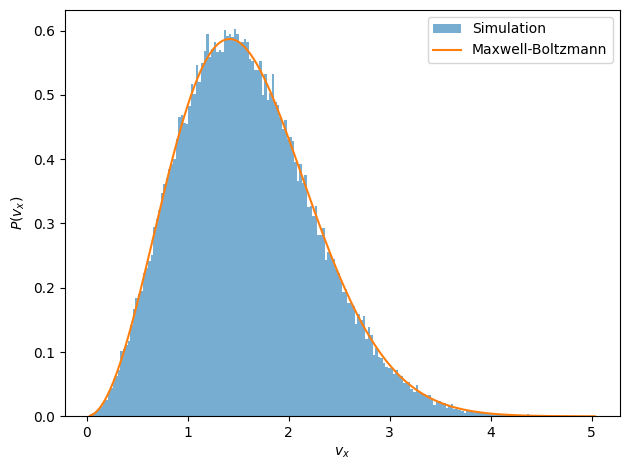

In [6]:
velocityMagnitudeDistr(system)

### Number of Particles in a Cell Distribution

In [7]:
def particlesInCellDistr(system):
    for i in range(10):
        streaming(system)
        collision(system)

    cells = distributeToCells(system)

    nInCell = np.array([len(cell) for cell in cells.flat])

    nMean = nInCell.mean()

    n_values = np.arange(0, nInCell.max() + 1)

    bin_edges = np.arange(
        nInCell.max() + 2
    ) - 0.5    

    plt.figure(figsize=(7, 4))

    plt.hist(
        nInCell,
        bins=bin_edges,
        density=True,
        alpha=0.6,
        label="Simulation"
    )


    plt.plot(
        n_values,
        poisson.pmf(n_values, nMean),
        "-",
        label=fr"Poisson, $\lambda={nMean:.2f}$"
    )

    plt.xlabel(r"Number of particles in a cell $N_c$")
    plt.ylabel(r"Probability $P(N_c)$")
    plt.title("Cell occupancy distribution")
    plt.legend()
    plt.tight_layout()

    plt.show()
    

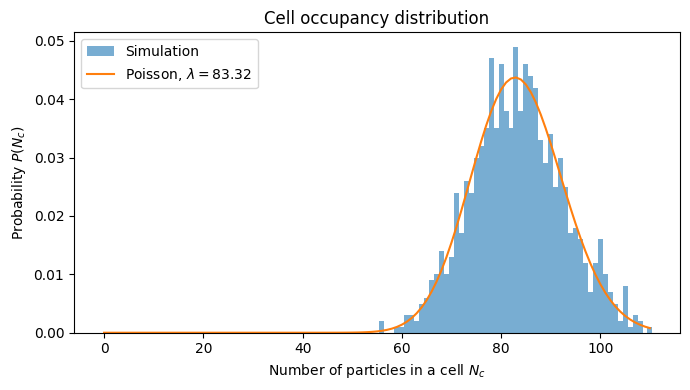

In [8]:
particlesInCellDistr(system)

#### Polymer

In [9]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../src")

from polymer import Polymer
from md import verlet_step
from forces import forcesOnPolymer

polymer = Polymer(
    nMonomers=10,
    bondLength=0.5,
    m=4,
    k=100,
    box=[10,10,10],
    kBT=1,
    seed=1337
)


### Genaration of a Polymer (__Linear__)

Rel. distnces between monomers:[np.float64(0.9944919623034857), np.float64(0.9878981817464435), np.float64(0.9755248500152203), np.float64(0.9794808806101237), np.float64(0.9728405300581202), np.float64(1.0212170262429352), np.float64(0.963766282543574), np.float64(1.0120167678176795), np.float64(0.9659187806689258)]


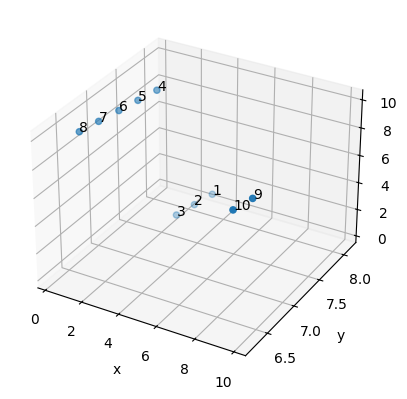

In [10]:
polymer.generateLinearPositions()

#print(f"Positions of monomers:{polymer.r}\n")
print(f"Rel. distnces between monomers:{[polymer.distInBC(i, i+1)/polymer.bondLength for i in range(0, polymer.nMonomers-1)]}") 

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    polymer.r[:, 0],
    polymer.r[:, 1],
    polymer.r[:, 2]
)
for i in range(len(polymer.r)):
    ax.text(polymer.r[i, 0], polymer.r[i, 1], polymer.r[i, 2], str(i+1))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

### Generation of a Polymer (Random Walk)

Rel. distnces between monomers:[np.float64(0.9983241909843626), np.float64(0.9888957667307038), np.float64(0.9562560421881949), np.float64(0.9888189559603535), np.float64(1.0000566845160326), np.float64(1.047174950124914), np.float64(0.9911974315181528), np.float64(0.9752140004166637), np.float64(0.9632501676868207)]


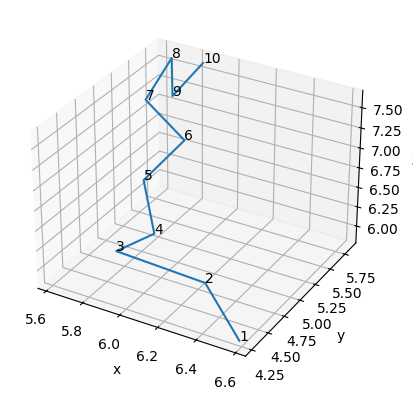

In [20]:
polymer.generateRandomWalk()

#print(f"Positions of monomers:{polymer.r}\n")
print(f"Rel. distnces between monomers:{[polymer.distInBC(i, i+1)/polymer.bondLength for i in range(0, polymer.nMonomers-1)]}") 

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    polymer.r[:, 0],
    polymer.r[:, 1],
    polymer.r[:, 2]
)
for i in range(len(polymer.r)):
    ax.text(polymer.r[i, 0], polymer.r[i, 1], polymer.r[i, 2], str(i+1))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

### Conserving Polymer Length

In [12]:
def average_length():
    res = 0
    for i in range(polymer.nMonomers-1):
        res += polymer.distInBC(i, i+1)
    return res/polymer.nMonomers


Shortest average: 0.40504389992275264/nLongest average0.5288828486517932/nDifference: 0.12383894872904061


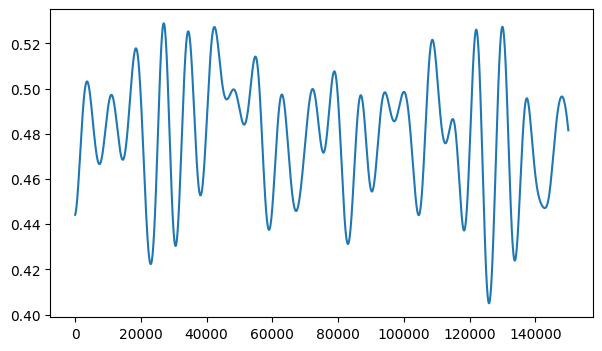

In [13]:

average = [average_length()]
for step in range(150000):
    verlet_step(polymer, 0.0001, forcesOnPolymer)
    average.append(average_length())

average = np.array(average)

print(f"Shortest average: {average.min()}/nLongest average{average.max()}/nDifference: {average.max() - average.min()}")

plt.figure(figsize=(7, 4))
plt.plot(average)
plt.show()

    


Actually it is better, than I expected it to be -- it makes sense, that it basically behaves like an osscilator around 0.5 (bond length)

### Conserving Polymer Energy

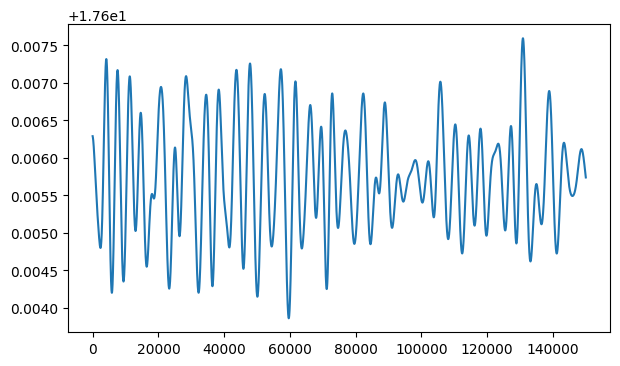

In [15]:
energy = [polymer.totalEnergy()]
for step in range(150000):
    verlet_step(polymer, 0.0001, forcesOnPolymer)
    energy.append(polymer.totalEnergy())

energy = np.array(energy)

plt.figure(figsize=(7, 4))
plt.plot(energy)
plt.show()
